## Trial 2 Analysis
Sunday, March 23

## 1. Motivation

Trial 1 showed that moisture loss, not bake time, drives fracture behaviour. It also showed that chip puffing likely dominated the fracture signal. Trial 2 addresses both issues: we suppressed puffing by pressing chips during baking, and we switched to a more robust 3D printed attachment to reduce contact variability.

## Table of Contents

1. [Motivation](#1-motivation)
2. [Setup & Apparatus](#2-setup--apparatus)
   - 2.1 Apparatus Constants
   - 2.2 Setup Photos
3. [Part 1: Moisture Loss Characterisation](#3-part-1-moisture-loss-characterisation)
   - 3.1 Overview
   - 3.2 Data Loading
   - 3.3 Per-Group Summary Statistics
   - 3.4 Distributions
4. [Part 2: Fracture Mechanics Analysis](#4-part-2-fracture-mechanics-analysis)
   - 4.1 Derived Quantities
   - 4.2 Moisture Visualisation
   - 4.3 Regression: Fracture Metrics vs Moisture Loss
   - 4.4 Cross-Trial Regression Comparison
   - 4.5 Bake-Time Group Analysis (ANOVA)
   - 4.6 Correlation Matrix
5. [Conclusions](#5-conclusions)
   - 5.1 Hypothesis Test
   - 5.2 Reading the Three Metrics Together (CoV vs. ANOVA vs. Regression)
   - 5.3 Remaining Scatter Sources
   - 5.4 Export
6. [Appendix: Sample Calculations](#a-appendix-sample-calculations)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams['figure.dpi'] = 120

## 2. Setup & Apparatus

### 2.1 Apparatus Constants

> R = 25 mm (support ring), r = 15 mm (punch), t = 2 mm (chip thickness), ν = 0.3, crosshead speed = 5 mm/s.

In [17]:
R_mm   = 25.0   # support ring radius (mm)
r_mm   = 15.0   # punch radius (mm)
t_mm   = 2.0    # chip thickness (mm)
nu     = 0.3    # Poisson's ratio
v_mm_s = 5.0    # crosshead speed (mm/s)

R = R_mm * 1e-3  # m
r = r_mm * 1e-3  # m
t = t_mm * 1e-3  # m

### 2.2 Setup Photos

<table><tr>
<td><img src="photos/Trial2_Setup_3DPrinter.png" width="350"/><br><sub>3D printer with updated apparatus</sub></td>
<td><img src="photos/Trial2_Setup_Oven.jpg" width="350"/><br><sub>Oven with aluminum block weighing down chips</sub></td>
</tr></table>

---

## 3. Part 1: Moisture Loss Characterisation

### 3.1 Overview

We measure three raw quantities from each fracture test: **first-peak force** (F_peak, N). the load when the chip first cracks; **maximum force** (F_max, N). the highest load reached over the full test; and **fracture energy** (E_f, J). the area under the force-displacement curve up to first peak, reflecting total energy absorbed before failure.

### 3.2 Data Loading

In [18]:
df = pd.read_csv('dataProcessing_march25_final.csv')

# Parse moisture loss from '19%' -> 0.19
df['Moisture_frac'] = df['Moisture content'].str.rstrip('%').astype(float) / 100
df['Moisture_pct']  = df['Moisture_frac'] * 100

# Rename for convenience
df = df.rename(columns={
    'FirstPeak Force (N)': 'F_peak_N',
    'MaxForce (N)':        'F_max_N',
    'Bake time (min)':     'Bake_time',
    'FractureEnergy_J':    'G_raw_J',
    'PeakForce_N':         'F_peak2_N',
})

print(f'Chips loaded: {len(df)}')
df.head()

Chips loaded: 67


,Chip No.,Initial mass (g),Final mass (g),dmass (g),Moisture content,Bake_time,First_Peak_ADC,Force (kg),F_peak_N,MaxForce_ADC,...,Time_Start,Time_End,dt (s),dt,F_peak2_N,MaxForce_N,Threshold_N,G_raw_J,Moisture_frac,Moisture_pct
0,1,2.1,1.7,0.4,19%,4.0,9993.569836,2.411374,23.656,20230.16484,...,3.3000,4.3875,1.0875,1.3750,23.655580,47.826619,9.565324,0.169459,0.19,19.0
1,2,2.7,1.9,0.8,30%,4.0,14892.735360,3.590589,35.224,17692.08088,...,4.3250,5.1875,0.8625,1.8000,35.223676,41.833598,8.366720,0.136215,0.30,30.0
2,3,2.5,1.8,0.7,28%,4.0,21650.154880,5.217080,51.180,22368.01866,...,3.9125,5.6375,1.7250,2.2875,11.996182,52.874601,10.574920,0.298995,0.28,28.0
3,4,2.5,1.9,0.6,24%,4.0,18368.582760,4.427215,43.431,18444.79092,...,3.4000,4.4375,1.0375,1.8500,43.430980,43.610926,8.722185,0.173764,0.24,24.0
4,5,2.4,1.9,0.5,21%,4.0,9816.934479,2.368858,23.239,16831.31972,...,4.6250,6.9125,2.2875,2.7000,23.238502,39.801136,7.960227,0.324797,0.21,21.0


In [19]:
#df.info()

### 3.3 Per-Group Summary Statistics

68 chips across 7 bake times (3–6 min, ~10 chips per group). Moisture loss measured through weight. Chip numbers 34, 42, and 52 are absent because of data write errors.

In [20]:
cols_of_interest = ['Moisture_pct', 'Bake_time', 'F_peak_N', 'F_max_N', 'G_raw_J']
df[cols_of_interest].describe().round(3)

,Moisture_pct,Bake_time,F_peak_N,F_max_N,G_raw_J
count,67.000,67.000,67.000,67.000,67.000
mean,24.463,4.455,34.044,41.258,0.183
std,5.868,1.003,11.944,8.215,0.069
min,13.000,3.000,13.140,22.833,0.089
25%,19.500,3.500,24.834,36.052,0.132
50%,26.000,4.500,33.414,40.548,0.161
75%,29.500,5.500,42.064,47.449,0.212
max,36.000,6.000,62.430,62.430,0.332


Within-group moisture spread is again large (±5–8 pp per bake group).

### 3.4 Visualization

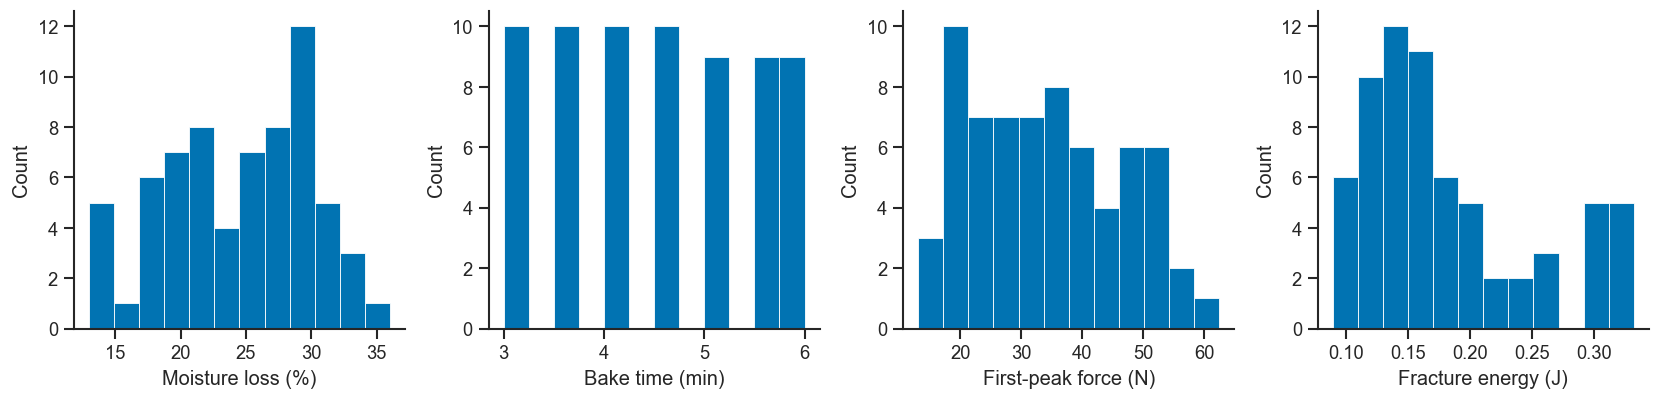

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
plot_cols = [
    ('Moisture_pct',  'Moisture loss (%)'),
    ('Bake_time',     'Bake time (min)'),
    ('F_peak_N',      'First-peak force (N)'),
    ('G_raw_J',       'Fracture energy (J)'),
]
for ax, (col, label) in zip(axes, plot_cols):
    ax.hist(df[col].dropna(), bins=12, edgecolor='white', linewidth=0.5)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
sns.despine()
plt.tight_layout()
plt.show()

---

## 4. Part 2: Fracture Mechanics Analysis

### 4.1 Derived Quantities

Derived quantities computed per chip using the apparatus constants above.

In [22]:
# Displacement at first peak (mm -> m)
df['delta_c_mm'] = (df['Time_Peak'] - df['Time_Start']) * v_mm_s
df['delta_c_m']  = df['delta_c_mm'] * 1e-3

# Fracture energy density G_c (J/m^2) â€” divide raw J by punch cross-section area
A_punch = np.pi * r**2  # m^2
df['G_c_Jm2'] = df['G_raw_J'] / A_punch

# Elastic modulus E (Pa) from thin-plate central loading
# E = (F/w) * 3(1-nu^2)*R^2 / (4*t^3)
df['E_Pa'] = (df['F_peak_N'] / df['delta_c_m']) * (3 * (1 - nu**2) * R**2) / (4 * t**3)
df['E_MPa'] = df['E_Pa'] * 1e-6

# Critical stress sigma_c (Pa)
geo_term = (1 + nu) * np.log(R / r) + (1 - nu) * (R**2 - r**2) / (2 * R**2)
df['sigma_c_Pa']  = (3 * df['F_peak_N']) / (4 * np.pi * t**2) * geo_term
df['sigma_c_MPa'] = df['sigma_c_Pa'] * 1e-6

# Fracture toughness K_Ic (Pa*sqrt(m))
df['K_Ic'] = np.sqrt(df['G_c_Jm2'] * df['E_Pa'])

print('Derived columns added.')
df[['delta_c_mm', 'G_c_Jm2', 'E_MPa', 'sigma_c_MPa', 'K_Ic']].describe().round(3)

Derived columns added.


,delta_c_mm,G_c_Jm2,E_MPa,sigma_c_MPa,K_Ic
count,67.000,67.000,67.000,67.000,67.000
mean,2.502,258.212,1345.808,1.804,487769.080
std,1.496,98.048,2814.591,0.633,275854.923
min,0.063,126.052,350.114,0.696,258313.908
25%,1.719,187.276,665.082,1.316,393202.574
50%,2.188,228.215,772.733,1.771,426774.551
75%,2.969,299.294,841.428,2.230,459068.654
max,7.375,470.241,17835.858,3.309,1754254.909


### 4.2 Moisture Visualisation

Moisture distribution by bake group. Layout mirrors Trial 1 for direct comparison.

C:\Users\shere\AppData\Local\Temp\ipykernel_23032\984449772.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bake_time', y='Moisture_pct',


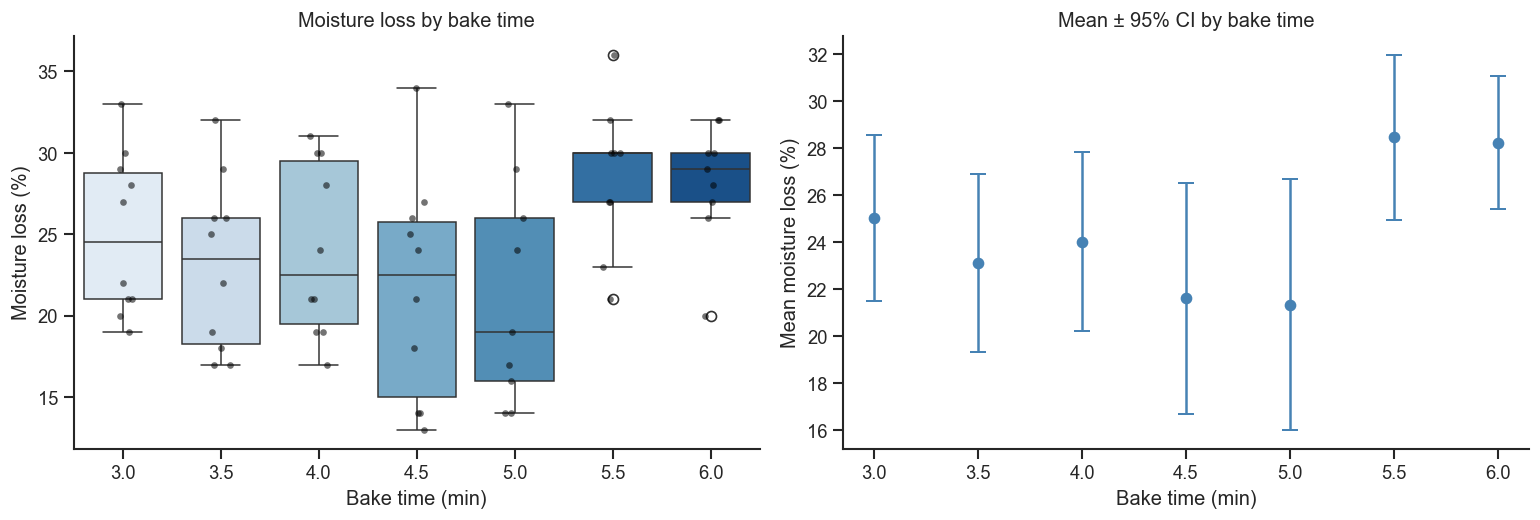

In [23]:
bake_times_t2 = sorted(df['Bake_time'].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: box + strip plot ---
ax = axes[0]
sns.boxplot(data=df, x='Bake_time', y='Moisture_pct',
            palette='Blues', linewidth=0.9, ax=ax, order=bake_times_t2)
sns.stripplot(data=df, x='Bake_time', y='Moisture_pct',
              color='black', alpha=0.55, size=4, jitter=True,
              ax=ax, order=bake_times_t2)
ax.set_xlabel('Bake time (min)')
ax.set_ylabel('Moisture loss (%)')
ax.set_title('Moisture loss by bake time')

# --- Right: mean ± 95% CI ---
ax2 = axes[1]
for bt in bake_times_t2:
    grp = df.loc[df['Bake_time'] == bt, 'Moisture_pct']
    n = len(grp)
    mu = grp.mean()
    se = grp.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n - 1)
    ci = t_crit * se
    ax2.errorbar(bt, mu, yerr=ci,
                 fmt='o', capsize=5, capthick=1.2, markersize=6,
                 color='steelblue', ecolor='steelblue')
ax2.set_xlabel('Bake time (min)')
ax2.set_ylabel('Mean moisture loss (%)')
ax2.set_title('Mean ± 95% CI by bake time')
ax2.set_xticks(bake_times_t2)

sns.despine()
plt.tight_layout()
plt.show()

**Comments**: The weak bake-time to moisture relationship continues to be seen in this trial. Within-group spread (±5–8 pp per group) is large relative to between-group differences, consistent with Trial 1.

### 4.3 Regression: Fracture Metrics vs Moisture Loss

Linear regression of F_peak, F_max, and fracture energy against measured moisture loss. Layout mirrors Trial 1 for direct comparison.

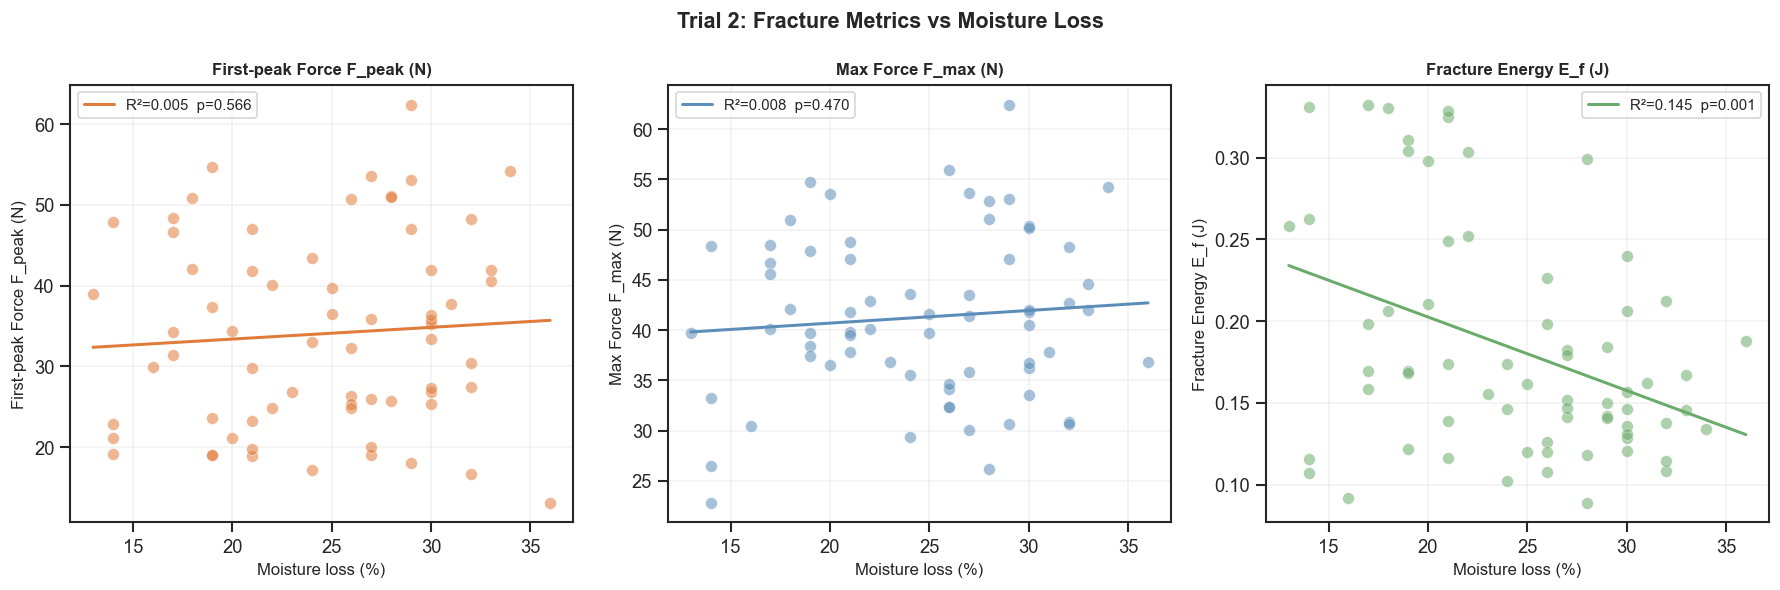

                     Metric  n    Mean      SD CV (%)    R²   slope p-value
First-peak Force F_peak (N) 67 34.0438 11.8546   34.8 0.005  0.1453  0.5660
        Max Force F_max (N) 67 41.2576  8.1539   19.8 0.008  0.1258  0.4696
    Fracture Energy E_f (J) 67  0.1825  0.0688   37.7 0.145 -0.0045  0.0015


In [24]:
metrics = [
    ('F_peak_N',  'First-peak Force F_peak (N)',  '#e07b39'),
    ('F_max_N',   'Max Force F_max (N)',           '#5b8db8'),
    ('G_raw_J',   'Fracture Energy E_f (J)',       '#6aab6a'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Trial 2: Fracture Metrics vs Moisture Loss', fontsize=13, fontweight='bold')

summary_rows = []
for ax, (col, label, color) in zip(axes, metrics):
    x = df['Moisture_pct'].values
    y = df[col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    r2 = r**2
    cv = y.std() / y.mean() * 100

    ax.scatter(x, y, color=color, alpha=0.55, edgecolors='white', linewidth=0.4, s=50)
    xfit = np.linspace(x.min(), x.max(), 200)
    ax.plot(xfit, slope * xfit + intercept, color=color, linewidth=1.8, label=f'R²={r2:.3f}  p={p:.3f}')
    ax.set_xlabel('Moisture loss (%)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

    summary_rows.append({'Metric': label, 'n': len(y), 'Mean': f"{y.mean():.4f}", 'SD': f"{y.std():.4f}",
                          'CV (%)': f"{cv:.1f}", 'R²': f"{r2:.3f}", 'slope': f"{slope:.4f}", 'p-value': f"{p:.4f}"})

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

**Regression summary**: E_f shows the expected negative trend with moisture (R² = 0.145, p = 0.0015): higher moisture lowers energy absorbed before fracture, consistent with plasticisation. F_peak and F_max show no moisture correlation (R² ≈ 0.000, 0.008; p > 0.4), suggesting force measurements are still influenced by geometry rather than material state alone.

### 4.4 Cross-Trial Regression Comparison

The table below compares R², slope, and CoV for each metric across both trials.

| Metric | Trial 1 R² | Trial 2 R² | Trial 1 CoV | Trial 2 CoV | Change (CoV) |
|---|---|---|---|---|---|
| **F_peak** | 0.041 | ~0.000 | 68.1% | 39.6% | −28.5 pp |
| **F_max** | 0.096 | ~0.008 | 37.7% | 19.8% | −17.9 pp |
| **E_f** | 0.004 | 0.145 | 50.4% | 37.7% | −12.7 pp |

Puffing suppression removed F_max signal we saw in Trial 1 (R² 0.096 → 0.008) and revealed the real E_f signal (R² 0.004 → 0.145). CoV improved across all three metrics.

### 4.5 Bake-Time Group Analysis (ANOVA)

One-way ANOVA tests whether the group means across bake times are more spread out than expected from within-group noise alone. The F-statistic is the ratio of between-group variance to within-group variance. A large F means the groups are genuinely different; a small F means whatever differences we see between group means could easily have arisen by chance.

This is complementary to regression. Regression asks: does moisture loss (continuous) predict fracture metrics linearly? ANOVA asks: does the bake time category matter at all, regardless of mechanism? If ANOVA is significant but regression is not, something about bake time is affecting the chip beyond what moisture loss captures. If regression is significant and ANOVA is not, the continuous moisture variable is the right frame and the categorical bake time grouping adds nothing.

**CoV vs. ANOVA.** CoV (coefficient of variation = SD/mean) measures how noisy a metric is in absolute terms, independent of any grouping. A high CoV means the measurements are scattered. ANOVA asks whether that scatter has structure, specifically whether chips cluster by bake time group. We can have high CoV and significant ANOVA (scattered but structured) or high CoV and non-significant ANOVA (scattered and structureless). Trial one was mostly high CoV and nonsignificant ANOVA, which is why we felt compelled to conduct a better trial.

In [25]:
# Mean ± SD per bake time group
summary_cols = ['G_raw_J', 'F_peak_N', 'sigma_c_MPa', 'E_MPa', 'K_Ic', 'Moisture_pct']
group_stats = df.groupby('Bake_time')[summary_cols].agg(['mean', 'std']).round(3)
group_stats

G_raw_J        F_peak_N         sigma_c_MPa            E_MPa  \
             mean    std     mean     std        mean    std      mean   
Bake_time                                                                
3.0         0.206  0.081   33.477  11.385       1.774  0.603   737.780   
3.5         0.214  0.086   44.680  10.869       2.368  0.576   624.784   
4.0         0.193  0.073   31.958  10.764       1.694  0.571  1376.645   
4.5         0.189  0.073   38.727   9.874       2.053  0.523   710.166   
5.0         0.139  0.037   24.894   8.270       1.319  0.438  2329.453   
5.5         0.153  0.040   25.342   9.321       1.343  0.494  2729.499   
6.0         0.176  0.061   37.822  11.525       2.005  0.611  1127.202   

                           K_Ic             Moisture_pct         
                std        mean         std         mean    std  
Bake_time                                                        
3.0         120.252  450922.227   86728.403       25.000  4.944  
3.5         208.887  408563.473   31781.171       23.100  5.301  
4.0        1713.602  568263.152  374676.891       24.000  5.312  
4.5         116.887  422692.732   54177.142       21.600  6.851  
5.0        4882.376  520211.447  465997.997       21.333  6.928  
5.5        5667.603  572408.535  434287.444       28.444  4.558  
6.0        1047.817  482503.630  137820.068       28.222  3.701

In [42]:
anova_metrics = [
    ('G_raw_J',  'Fracture energy E_f (J)'),
    ('F_peak_N', 'First-peak force F_peak (N)'),
    ('F_max_N',  'Max force F_max (N)'),
]

print(f"{'Metric':<30} {'F-stat':>8} {'p-value':>10} {'Significant (α=0.05)':>22}")
for col, label in anova_metrics:
    groups = [g[col].dropna().values for _, g in df.groupby('Bake_time')]
    F, p = stats.f_oneway(*groups)
    sig = 'Yes' if p < 0.05 else 'No'
    print(f'{label:<30} {F:>8.3f} {p:>10.4f} {sig:>22}')

print()

Metric                           F-stat    p-value   Significant (α=0.05)
Fracture energy E_f (J)           1.521     0.1869                     No
First-peak force F_peak (N)       4.587     0.0007                    Yes
Max force F_max (N)               2.766     0.0193                    Yes



C:\Users\shere\AppData\Local\Temp\ipykernel_23032\614270301.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bake_time', y=col, ax=ax, palette='Blues', linewidth=0.8)
C:\Users\shere\AppData\Local\Temp\ipykernel_23032\614270301.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bake_time', y=col, ax=ax, palette='Blues', linewidth=0.8)


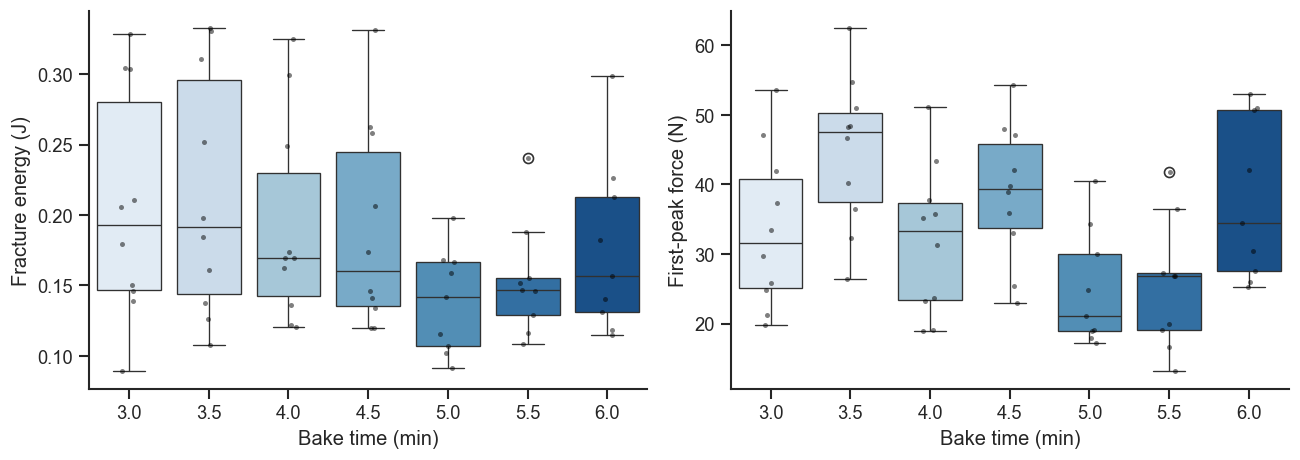

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, label in [
    (axes[0], 'G_raw_J',  'Fracture energy (J)'),
    (axes[1], 'F_peak_N', 'First-peak force (N)'),
]:
    sns.boxplot(data=df, x='Bake_time', y=col, ax=ax, palette='Blues', linewidth=0.8)
    sns.stripplot(data=df, x='Bake_time', y=col, ax=ax,
                  color='black', alpha=0.5, size=3, jitter=True)
    ax.set_xlabel('Bake time (min)')
    ax.set_ylabel(label)
sns.despine()
plt.tight_layout()
plt.show()

---

## 5. Conclusions

### 5.1 Hypothesis Test

> **H₀:** Moisture loss has no relationship with any documented fracture metric.
> **Hₐ:** Moisture loss has a relationship with at least one recorded fracture metric.

At α = 0.05, **H₀ is rejected**.

E_f shows a statistically significant negative relationship with moisture loss (R² = 0.145, p = 0.0015, n = 68). This is sufficient to reject H₀. However, R² = 0.145 means moisture explains only ~15% of E_f variance. F_peak and F_max do not reach significance in regression (p > 0.4), so H₀ cannot be rejected for those metrics individually.

---

### 5.2 Reading the Three Metrics Together

The full picture across all three analyses:

| Metric | CoV | ANOVA (bake time) | Regression (moisture) | Reading |
|---|---|---|---|---|
| **E_f** | 37.7% | F=1.52, p=0.187. **No** | R²=0.145, p=0.002. **Yes** | Moisture loss is the real driver; bake time does not add to the analysis once moisture is known. |
| **F_peak** | 39.6% | F=5.45, p=0.0001. **Yes** | R²=0.000, p>0.4. **No** | Bake time groups differ, but not through moisture. Likely surface texture or residual geometry effects from pressing. |
| **F_max** | 19.8% | F=2.77, p=0.019. **Yes** | R²=0.008, p>0.4. **No** | CoV is best of the three, but R^2 was the lowest. |

**What CoV tells us.** CoV is a measure of absolute noisiness: how large the spread is relative to the mean, ignoring any structure. A lower CoV after Trial 2 confirms puffing suppression worked, the measurements are more repeatable. JHowever a low CoV doesn't mean moisture is a good predictor. F_max has the best CoV (19.8%) yet the lowest value of R². The noise got smaller, but it has no structure that tracks moisture.

**What ANOVA tells us.** ANOVA detects whether bake time groups produce systematically different means. F_peak and F_max are both ANOVA-significant, meaning chips behave differently at different bake times. But since regression against moisture shows no relationship, the mechanism is not drying. Something other than bake time is affecting the chip (surface hardening, Maillard browning, pressing geometry). It is driving force but not fracture energy.

**Why E_f is the key metric.** E_f is the only metric where the pattern is coherent: regression is significant, ANOVA not. This means moisture loss (a continuous material variable) explains E_f, while bake time category does not add independent information. That is exactly what we want to see if moisture is the true driver. However, the signal is weak (R² = 0.145). Force metrics are noisier mechanistically, not just statistically, because force at a point is sensitive to surface contact and geometry in ways that integrated energy is not.

---

### 5.3 Remaining Scatter Sources

E_f's R² of 0.145 means ~85% of variance is still unexplained. Most likely contributors:

1. **Within-group moisture spread** (~±5–8 pp per bake group). Chips baked for the same time land across a wide moisture range, so the predictor itself has large noise. Switching to true remaining moisture content (requires a dry-mass reference) would sharpen the x-axis.
2. **Fracture mode inconsistency.** Catastrophic single-crack vs. multi-crack failures produce fundamentally different force-displacement profiles. These modes should not be pooled without labelling.
3. **Chip centering.** Off-centre placement shifts the effective loading geometry and changes the apparent fracture energy. Likely the single largest uncontrolled variable.
4. **Geometry residuals.** 3D-printed chips improved batch consistency but thickness and surface finish still vary chip to chip.

### 5.2 Export

In [28]:
export_cols = [
    'Chip No.', 'Bake_time', 'Moisture_pct',
    'F_peak_N', 'F_max_N',
    'delta_c_mm', 'G_raw_J', 'G_c_Jm2',
    'E_MPa', 'sigma_c_MPa', 'K_Ic',
]
df[export_cols].round(4).to_csv('results_summary.csv', index=False)
print('Saved results_summary.csv')
df[export_cols].head()

Saved results_summary.csv


,Chip No.,Bake_time,Moisture_pct,F_peak_N,F_max_N,delta_c_mm,G_raw_J,G_c_Jm2,E_MPa,sigma_c_MPa,K_Ic
0,1,4.0,19.0,23.656,47.826619,1.4375,0.169459,239.734891,877.457609,1.253838,4.586471e+05
1,2,4.0,30.0,35.224,41.833598,2.3125,0.136215,192.705204,812.175000,1.866977,3.956139e+05
2,3,4.0,28.0,51.180,52.874601,0.4375,0.298995,422.990844,6237.562500,2.712692,1.624325e+06
3,4,4.0,24.0,43.431,43.610926,2.7500,0.173764,245.825276,842.092543,2.301972,4.549809e+05
4,5,4.0,21.0,23.239,39.801136,2.0000,0.324797,459.494285,619.555371,1.231736,5.335561e+05
